# Phase 4: Tiered Report System

The Phase 1–3 pipeline produces a single `gap_report` dict. Phase 4 reshapes it into something **two audiences** can use:

- **Executives / PMs** need a 10-second verdict: good or bad, what to do next.
- **Practitioners** need the detail: per-cluster stats, every gap, the actual plot.

| Sub-phase | Change |
|-----------|--------|
| 4.1 | Three tiers — Executive Summary, Priority Gaps, Full Breakdown — built in a dedicated `gap_report.py` module. |
| 4.2 | `ShowGapReport` renders typed FO views: `Header`, severity-coded `Notice`/`Error`/`Warning`/`Success`, `TableView`. No wall of markdown. |
| 4.3 | `ExportCoverageReport` operator → single-file HTML with inline SVG UMAP plot and base64 CSV download. |
| 4.4 | Coverage history on `dataset.info["coverage_history"]` + a **"Since last run"** diff at the top of subsequent reports. |

This notebook loads the plugin's production modules (`gap_report.py`, `report_export.py`) and drives them directly against a fabricated fixture — no FiftyOne App, no Twelve Labs calls.

## 0. Setup

Load `gap_report` + `report_export` as a synthetic package. The plugin's `__init__.py` pulls in FiftyOne, TwelveLabs, HDBSCAN, etc., but these two modules are dependency-light — only `stdlib` + `gap_report`'s `collections`/`datetime`. This side-steps the heavy init while still exercising the real code the operator runs.

In [1]:
import importlib.util, sys, types
from pathlib import Path

plugin_root = Path("..").resolve()
pkg_name = "vcga_demo"

# Synthetic package so `from .gap_report import ...` inside report_export.py resolves.
pkg = types.ModuleType(pkg_name)
pkg.__path__ = [str(plugin_root)]
sys.modules[pkg_name] = pkg

def _load(name):
    spec = importlib.util.spec_from_file_location(
        f"{pkg_name}.{name}", plugin_root / f"{name}.py"
    )
    m = importlib.util.module_from_spec(spec)
    sys.modules[f"{pkg_name}.{name}"] = m
    spec.loader.exec_module(m)
    return m

gr  = _load("gap_report")       # tier builders + render + history + diff
rex = _load("report_export")    # HTML/SVG/CSV exporter

print("loaded:", gr.__name__, rex.__name__)
print("HISTORY_INFO_KEY =", gr.HISTORY_INFO_KEY)

loaded: vcga_demo.gap_report vcga_demo.report_export
HISTORY_INFO_KEY = coverage_history


## 1. Qualitative bands

Tier 1 maps the raw `coverage_score` (0–1) to a qualitative label; Tier 2 maps each gap's `priority_score` (0–100) to a severity bucket. Boundaries (from the phase spec):

| Coverage % | Label |
|------------|-------|
| `< 30`     | Poor (error) |
| `30 – <55` | Fair (warning) |
| `55 – <80` | Good (success) |
| `≥ 80`     | Excellent (success) |

| Priority score | Severity |
|----------------|----------|
| `> 70`        | Critical |
| `40 – ≤70`    | Moderate |
| `< 40`        | Low |

In [2]:
print("coverage_quality boundaries:")
for pct in [0, 29.9, 30, 54.9, 55, 79.9, 80, 100]:
    print(f"  {pct:5.1f}%  -> {gr.coverage_quality(pct)}")

print("\nseverity_label boundaries:")
for s in [0, 39.9, 40, 70, 70.1, 85, 100]:
    print(f"  {s:5.1f}    -> {gr.severity_label(s)}")

coverage_quality boundaries:
    0.0%  -> Poor
   29.9%  -> Poor
   30.0%  -> Fair
   54.9%  -> Fair
   55.0%  -> Good
   79.9%  -> Good
   80.0%  -> Excellent
  100.0%  -> Excellent

severity_label boundaries:
    0.0    -> Low
   39.9    -> Low
   40.0    -> Moderate
   70.0    -> Moderate
   70.1    -> Critical
   85.0    -> Critical
  100.0    -> Critical


## 2. Fabricate a realistic `gap_report`

The tiered builders are pure-ish — they take a `gap_report` dict + a dataset. We construct both here so the rest of the notebook runs without any FiftyOne/API setup. The fixture mirrors what `detect_gaps` would emit after the Phase 3 pipeline: a coverage score, sparse clusters, flat + hierarchical category gaps, all with `priority_score` already attached (Phase 3.2).

In [3]:
# Mock dataset so Tier 3 + HTML export can iterate samples and look up fields.
class MockSample:
    __slots__ = ("_d", "filepath")
    def __init__(self, **kwargs):
        self.filepath = kwargs.pop("filepath", "video.mp4")
        self._d = kwargs
    def __getitem__(self, k): return self._d[k]
    def get_field(self, k):   return self._d.get(k)

class MockDataset:
    def __init__(self, name, samples):
        self.name = name
        self.samples = list(samples)
        self.info = {}
    def __iter__(self): return iter(self.samples)
    def __len__(self):  return len(self.samples)

# Build 3 clusters of 10 samples each + 2 outliers
import random
rng = random.Random(0)

def mk_samples(cid, n, *, base_dist=0.15, umap_center=(0, 0), label="", diversity=""):
    out = []
    for i in range(n):
        jitter = rng.random() * 0.18
        out.append(MockSample(
            filepath=f"{label or 'v'}_{cid}_{i}.mp4",
            cluster_id=cid,
            centroid_distance=base_dist + jitter,
            is_outlier=False,
            umap_x=umap_center[0] + rng.gauss(0, 0.8),
            umap_y=umap_center[1] + rng.gauss(0, 0.8),
            cluster_label=label or f"Cluster {cid}",
            cluster_diversity=diversity,
        ))
    return out

samples = (
    mk_samples(0, 10, base_dist=0.10, umap_center=(-4, 2),
               label="warehouse forklift forward",
               diversity="narrow aisle; loaded pallet")
    + mk_samples(1, 10, base_dist=0.12, umap_center=(3, 3),
                 label="outdoor ladder climb",
                 diversity="overcast; hard hat visible")
    + mk_samples(5, 2, base_dist=0.30, umap_center=(-1, -5),
                 label="garage vehicle inspection",
                 diversity="close-up of wheel; oil drip")
    # two noise points
    + [MockSample(filepath="noise_0.mp4", cluster_id=-1, centroid_distance=0.95,
                  is_outlier=True, umap_x=8, umap_y=-6,
                  cluster_label="Outliers (HDBSCAN noise)", cluster_diversity="")]
    + [MockSample(filepath="noise_1.mp4", cluster_id=-1, centroid_distance=0.92,
                  is_outlier=True, umap_x=-9, umap_y=7,
                  cluster_label="Outliers (HDBSCAN noise)", cluster_diversity="")]
)
dataset = MockDataset("safety-pilot", samples)

# Hand-crafted gap_report mirroring what Phase 3 would produce
gap_report = {
    "coverage_score": 0.42,
    "sparse_clusters": [
        {"cluster_id": 5, "label": "garage vehicle inspection",
         "count": 2, "priority_score": 55.0},
    ],
    "category_gaps": [
        {"category": "elevated platform", "closest_cluster": "outdoor ladder climb",
         "similarity": 0.02, "umap_x": 3, "umap_y": 3, "priority_score": 98.0},
        {"category": "loading", "closest_cluster": "warehouse forklift forward",
         "similarity": 0.08, "umap_x": -4, "umap_y": 2, "priority_score": 94.0},
        {"category": "turning", "closest_cluster": "warehouse forklift forward",
         "similarity": 0.05, "umap_x": -4, "umap_y": 2, "priority_score": 93.0},
    ],
    "category_hierarchy": [
        {"parent": "forklift operations", "n_covered": 1, "n_children": 4,
         "coverage": 0.25, "best_similarity": 0.97, "children": [
            {"category": "forward", "similarity": 0.97, "is_gap": False,
             "closest_cluster": "warehouse forklift forward"},
            {"category": "reverse", "similarity": 0.12, "is_gap": True,
             "closest_cluster": "warehouse forklift forward", "priority_score": 88.0},
            {"category": "loading", "similarity": 0.08, "is_gap": True,
             "closest_cluster": "warehouse forklift forward", "priority_score": 94.0},
            {"category": "turning", "similarity": 0.05, "is_gap": True,
             "closest_cluster": "warehouse forklift forward", "priority_score": 93.0},
        ]},
        {"parent": "fall hazards", "n_covered": 1, "n_children": 2,
         "coverage": 0.5, "best_similarity": 0.97, "children": [
            {"category": "ladder climb", "similarity": 0.97, "is_gap": False,
             "closest_cluster": "outdoor ladder climb"},
            {"category": "elevated platform", "similarity": 0.02, "is_gap": True,
             "closest_cluster": "outdoor ladder climb", "priority_score": 98.0},
        ]},
    ],
}
print(f"dataset: {dataset.name} ({len(dataset)} samples)")
print(f"gap_report: coverage={gap_report['coverage_score']:.2f}, "
      f"{len(gap_report['category_gaps'])} category gaps, "
      f"{len(gap_report['sparse_clusters'])} sparse cluster")

dataset: safety-pilot (24 samples)
gap_report: coverage=0.42, 3 category gaps, 1 sparse cluster


## 3. Tier 1 — Executive Summary

`build_executive_summary(gap_report, dataset)` walks the dataset once to count videos + non-noise clusters, picks the single highest-priority gap as the recommendation driver, and returns a ready-to-render dict.

In [4]:
tier1 = gr.build_executive_summary(gap_report, dataset)
for k, v in tier1.items():
    print(f"  {k:22s} = {v}")

print("\n>>> Actionable sentence:")
print(" ", tier1["recommendation"])

  coverage_score         = 0.42
  coverage_pct           = 42.0
  coverage_quality       = Fair
  total_videos           = 24
  total_clusters         = 3
  n_category_gaps        = 3
  n_sparse_clusters      = 1
  n_gaps_total           = 4
  recommendation         = Prioritize collecting videos that depict 'elevated platform' (nearest existing cluster: 'outdoor ladder climb') — priority 98/100, the most urgent gap.
  diff                   = None

>>> Actionable sentence:
  Prioritize collecting videos that depict 'elevated platform' (nearest existing cluster: 'outdoor ladder climb') — priority 98/100, the most urgent gap.


## 4. Tier 2 — Priority Gaps

`build_priority_gaps(gap_report, max_gaps=10)` merges the flat `category_gaps` and `sparse_clusters` lists, sorts by `priority_score` desc, tags each with a **severity** label, and attaches a concrete **collection recommendation** based on severity (Critical → ~8 videos, Moderate → 5, Low → 3).

In [5]:
tier2 = gr.build_priority_gaps(gap_report)
print(f"Top {len(tier2)} gaps, ranked:\n")
for i, e in enumerate(tier2, 1):
    print(f"  {i}. [{e['severity']:8s}  {e['priority_score']:5.1f}/100]  {e['name']}")
    print(f"       closest cluster: {e['closest_cluster']!r}  sim={e['similarity']:.2f}")
    print(f"       action: {e['collection_recommendation']}")
    print()

Top 4 gaps, ranked:

  1. [Critical   98.0/100]  elevated platform
       closest cluster: 'outdoor ladder climb'  sim=0.02
       action: Collect ~8 videos depicting 'elevated platform' from varied angles, subjects, and settings.

  2. [Critical   94.0/100]  loading
       closest cluster: 'warehouse forklift forward'  sim=0.08
       action: Collect ~8 videos depicting 'loading' from varied angles, subjects, and settings.

  3. [Critical   93.0/100]  turning
       closest cluster: 'warehouse forklift forward'  sim=0.05
       action: Collect ~8 videos depicting 'turning' from varied angles, subjects, and settings.

  4. [Moderate   55.0/100]  Sparse cluster 5: garage vehicle inspection
       closest cluster: 'garage vehicle inspection'  sim=1.00
       action: Collect ~5 more videos similar to 'garage vehicle inspection' (currently 2) to densify the cluster.



## 5. Tier 3 — Full Breakdown

`build_full_breakdown` iterates the dataset to compute per-cluster size, mean + max centroid distance, and pulls the Pegasus `cluster_label` / `cluster_diversity` from any one sample in the cluster. It also collects the *well-covered* categories from `category_hierarchy` — the children with `is_gap == False`, so readers can confirm what's already in good shape.

In [6]:
tier3 = gr.build_full_breakdown(gap_report, dataset)

print("Per-cluster stats:")
for c in tier3["clusters"]:
    print(f"  cluster {c['cluster_id']}  size={c['size']:3d}  {c['status']:13s}  "
          f"mean_d={c['mean_centroid_distance']:.2f}  max_d={c['max_centroid_distance']:.2f}")
    print(f"      label:     {c['cluster_label']!r}")
    print(f"      diversity: {c['cluster_diversity']!r}")

print(f"\nOutliers (HDBSCAN noise): {tier3['n_outliers']}")

print(f"\nWell-covered categories ({len(tier3['well_covered_categories'])}):")
for wc in tier3["well_covered_categories"]:
    print(f"  - {wc['parent']!r} → {wc['category']!r}  sim={wc['similarity']:.2f}")

Per-cluster stats:
  cluster 0  size= 10  well-covered   mean_d=0.20  max_d=0.25
      label:     'warehouse forklift forward'
      diversity: 'narrow aisle; loaded pallet'
  cluster 1  size= 10  well-covered   mean_d=0.23  max_d=0.28
      label:     'outdoor ladder climb'
      diversity: 'overcast; hard hat visible'
  cluster 5  size=  2  sparse         mean_d=0.43  max_d=0.45
      label:     'garage vehicle inspection'
      diversity: 'close-up of wheel; oil drip'

Outliers (HDBSCAN noise): 2

Well-covered categories (2):
  - 'forklift operations' → 'forward'  sim=0.97
  - 'fall hazards' → 'ladder climb'  sim=0.97


## 6. Full markdown rendering

`build_tiered_report` aggregates all three tiers into one dict; `render_tiered_report_md` turns it into the markdown you'd see in the FiftyOne App panel or on disk. With no `diff` argument, the "Since last run" section is silently omitted.

In [7]:
tiered = gr.build_tiered_report(gap_report, dataset)  # diff=None → no diff block
md = gr.render_tiered_report_md(tiered)

# Print only the first 40 lines so the notebook stays readable
for line in md.splitlines()[:40]:
    print(line)
print(f"\n... ({len(md.splitlines())} total lines)")

# Gap Analysis Report

## Tier 1 — Executive Summary

- **Coverage:** 42.0% — **Fair**
- **Videos analyzed:** 24
- **Clusters found:** 3
- **Gaps detected:** 4 (3 category, 1 sparse)
- **Recommended next step:** Prioritize collecting videos that depict 'elevated platform' (nearest existing cluster: 'outdoor ladder climb') — priority 98/100, the most urgent gap.

## Tier 2 — Priority Gaps

Top 4 gaps ranked by priority (Critical > 70, Moderate 40–70, Low < 40):

| # | Severity | Priority | Gap | Closest Cluster | Sim | Recommendation |
|---|----------|----------|-----|-----------------|-----|----------------|
| 1 | **Critical** | 98/100 | elevated platform | outdoor ladder climb | 0.02 | Collect ~8 videos depicting 'elevated platform' from varied angles, subjects, and settings. |
| 2 | **Critical** | 94/100 | loading | warehouse forklift forward | 0.08 | Collect ~8 videos depicting 'loading' from varied angles, subjects, and settings. |
| 3 | **Critical** | 93/100 | turning | warehouse 

## 7. Coverage history + diff

Phase 4.4 turns the report from a one-shot audit into a tracker. After every analysis run, `AnalyzeCoverage.execute` appends a lightweight entry to `dataset.info["coverage_history"]`:

```
{ timestamp, coverage_score, n_samples, n_clusters, n_sparse_clusters,
  gaps: [{name, priority_score, type}, ...] }
```

`compute_coverage_diff(current, previous)` matches gap names between two entries and returns a dict of what changed.

In [8]:
entry = gr.build_coverage_history_entry(gap_report, dataset)
import json
print(json.dumps(entry, indent=2)[:600] + "\n...")

{
  "timestamp": "2026-04-18T11:59:31",
  "coverage_score": 0.42,
  "n_samples": 24,
  "n_clusters": 3,
  "n_sparse_clusters": 1,
  "gaps": [
    {
      "name": "elevated platform",
      "priority_score": 98.0,
      "type": "category"
    },
    {
      "name": "loading",
      "priority_score": 94.0,
      "type": "category"
    },
    {
      "name": "turning",
      "priority_score": 93.0,
      "type": "category"
    },
    {
      "name": "garage vehicle inspection",
      "priority_score": 55.0,
      "type": "sparse_cluster"
    }
  ]
}
...


## 8. Two-run diff demo

Simulate a team addressing gaps:

- **Run 1** (our fixture): coverage 42%, gaps `['elevated platform', 'loading', 'turning']` + a sparse cluster.
- **Run 2**: dataset grows by 5 videos; two of the forklift gaps close.

The diff block should tell the user *which* gaps closed, which are *still open*, which are *newly opened*, and by how much coverage moved.

In [9]:
# Run 1 = the fixture we already built
run1 = gr.build_coverage_history_entry(gap_report, dataset)

# Run 2: 5 more samples added + two gaps closed + one slightly better score
run2_report = {
    "coverage_score": 0.58,
    "sparse_clusters": [],
    "category_gaps": [
        {"category": "elevated platform", "closest_cluster": "outdoor ladder climb",
         "similarity": 0.05, "priority_score": 96.0},
        {"category": "reverse", "closest_cluster": "warehouse forklift forward",
         "similarity": 0.22, "priority_score": 82.0},
    ],
    "category_hierarchy": [],
}
# Simulate dataset growth
larger = MockDataset("safety-pilot", list(samples) + [MockSample(
    filepath=f"new_{i}.mp4", cluster_id=0, centroid_distance=0.18,
    is_outlier=False, umap_x=-4 + rng.gauss(0, 0.6), umap_y=2 + rng.gauss(0, 0.6),
    cluster_label="warehouse forklift forward", cluster_diversity="new batch",
) for i in range(5)])
run2 = gr.build_coverage_history_entry(run2_report, larger)

diff = gr.compute_coverage_diff(run2, run1)
for k, v in diff.items():
    print(f"  {k:22s} = {v}")

  previous_timestamp     = 2026-04-18T11:59:31
  coverage_score_prev    = 0.42
  coverage_score_curr    = 0.58
  coverage_delta         = 0.16
  coverage_delta_pct     = 16.0
  n_samples_prev         = 24
  n_samples_curr         = 29
  new_samples            = 5
  closed_gaps            = ['garage vehicle inspection', 'loading', 'turning']
  still_open_gaps        = ['elevated platform']
  newly_opened_gaps      = ['reverse']


In [10]:
# Render the full tiered report WITH the diff → 'Since last run' block appears first
tiered_v2 = gr.build_tiered_report(run2_report, larger, diff=diff)
md_v2 = gr.render_tiered_report_md(tiered_v2)

# Print only the first 25 lines — the diff block + start of Tier 1
for line in md_v2.splitlines()[:25]:
    print(line)

# Gap Analysis Report

## Since last run (2026-04-18T11:59:31)

- **Coverage:** 42.0% → 58.0% (+16.0 pts)
- **Samples:** 24 → 29 (+5)
- ✓ **Closed gaps (3):** garage vehicle inspection, loading, turning
- ✗ **Still open (1):** elevated platform
- ⚠ **Newly opened (1):** reverse

## Tier 1 — Executive Summary

- **Coverage:** 58.0% — **Good**
- **Videos analyzed:** 29
- **Clusters found:** 3
- **Gaps detected:** 2 (2 category, 0 sparse)
- **Recommended next step:** Prioritize collecting videos that depict 'elevated platform' (nearest existing cluster: 'outdoor ladder climb') — priority 96/100, the most urgent gap.

## Tier 2 — Priority Gaps

Top 2 gaps ranked by priority (Critical > 70, Moderate 40–70, Low < 40):

| # | Severity | Priority | Gap | Closest Cluster | Sim | Recommendation |
|---|----------|----------|-----|-----------------|-----|----------------|
| 1 | **Critical** | 96/100 | elevated platform | outdoor ladder climb | 0.05 | Collect ~8 videos depicting 'elevated platform'

## 9. Self-contained HTML export

`report_export.export_coverage_report(dataset, gap_report, output_path)` writes a single-file HTML document that bundles:

- The full three-tier text report as styled HTML tables + headings.
- An **inline SVG** UMAP scatter plot rendered from `umap_x` / `umap_y` — colored by cluster, hollow-gray for outliers, hollow-red diamonds for missing-category markers.
- A **base64 data-URI download link** for a per-cluster CSV.
- Any "Since last run" diff (pulled from `dataset.info["coverage_history"]` automatically).

No external `<link>` / `<script>` / `src="http…"` references — a colleague without FiftyOne can open it in any browser.

In [11]:
import tempfile, os, re
from pathlib import Path

# Attach a history trail so the export can include a "Since last run" block
larger.info[gr.HISTORY_INFO_KEY] = [run1, run2]

out = Path(tempfile.gettempdir()) / "phase4_demo_report.html"
summary = rex.export_coverage_report(larger, run2_report, out)
print(f"wrote {summary['size_bytes']:,} bytes to {summary['output_path']}")
print(f"  samples plotted: {summary['n_samples']}  clusters in CSV: {summary['n_clusters']}")

html = out.read_text()
# Self-containment check — no external refs
external = re.search(r'<(link|script)|src="http', html, flags=re.IGNORECASE)
print("  external references:", "none ✓" if external is None else external.group(0))

# Confirm tier headings, diff block, SVG, CSV data URL all present
for needle in ("Tier 1 — Executive Summary", "Tier 2 — Priority Gaps",
               "Tier 3 — Full Breakdown", "Since last run",
               "<svg", "data:text/csv;base64,"):
    print(f"  contains {needle!r}:", "✓" if needle in html else "✗")

wrote 13,991 bytes to /private/var/folders/66/w13bdrhd2fb5hr9pq_f_46w00000gn/T/phase4_demo_report.html
  samples plotted: 29  clusters in CSV: 3
  external references: none ✓
  contains 'Tier 1 — Executive Summary': ✓
  contains 'Tier 2 — Priority Gaps': ✓
  contains 'Tier 3 — Full Breakdown': ✓
  contains 'Since last run': ✓
  contains '<svg': ✓
  contains 'data:text/csv;base64,': ✓


### Preview: the inline SVG

Jupyter can render the embedded scatter plot directly from the exported HTML. The plot shows:

- Filled circles coloured by cluster
- Hollow gray circles for HDBSCAN outliers
- Hollow red diamonds for missing-category markers (placed at the closest cluster's UMAP centroid)
- A right-hand legend

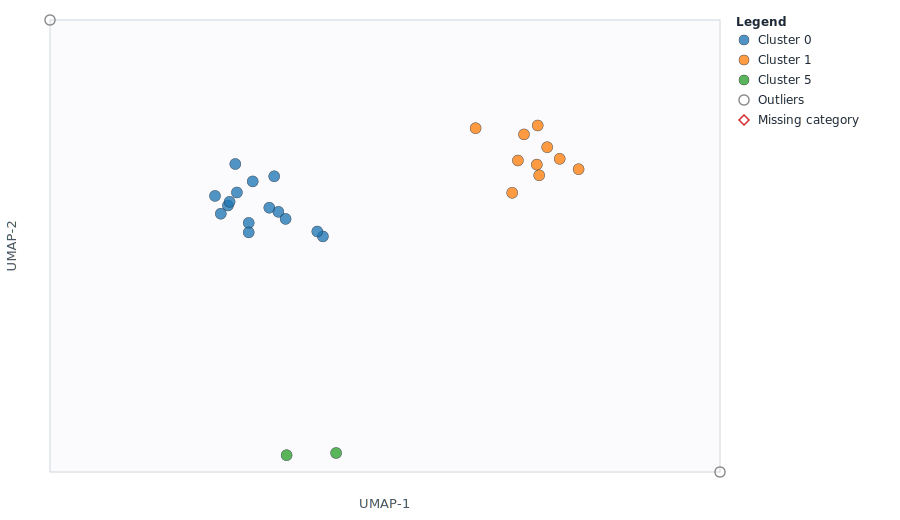

In [12]:
from IPython.display import SVG, display
# Extract the single <svg>...</svg> block the exporter embedded
m = re.search(r"<svg[\s\S]*?</svg>", html)
if m:
    display(SVG(data=m.group(0)))
else:
    print("(no SVG in export)")

## 10. How the plugin ties this to FiftyOne

Sub-phase 4.2 replaces a monolithic markdown string with typed FO output views. The `ShowGapReport` operator's `resolve_output` now builds a property tree like this (abbreviated from `__init__.py`):

```python
quality = result["coverage_quality"]
# Severity-coded notice — the first thing the user sees
if quality == "Poor":        notice_cls = types.Error
elif quality == "Fair":      notice_cls = types.Warning
else:                         notice_cls = types.Success  # Good / Excellent

if result["has_diff"]:
    # Pinned above everything — 'Since last run' with trend-coded severity
    outputs.view("since_last_run", _trend_view(result["diff_trend"])(
        label=result["diff_label"], description=result["diff_description"]))

outputs.view("tier1_header", types.Header(label="Tier 1 — Executive Summary", divider=True))
outputs.view("coverage_notice", notice_cls(label=coverage_label, description=recommendation))
outputs.int("total_videos", label="Videos analyzed")
# ... numeric stats ...

outputs.view("tier2_header", types.Header(label="Tier 2 — Priority Gaps", divider=True))
priority_table = types.TableView()
for col in ("rank", "severity", "priority_score", "name", "closest_cluster",
            "similarity", "collection_recommendation"):
    priority_table.add_column(col, label=...)
outputs.list("priority_rows", types.Object(), view=priority_table)

outputs.view("tier3_header", types.Header(label="Tier 3 — Full Breakdown", divider=True))
# ... cluster_rows TableView, outliers Notice, well_covered_rows TableView ...
```

The App panel renders these in declaration order: a coloured "Since last run" banner at the top (when there's history), then the Executive Summary's coverage notice and stats, then two sortable tables. No scrolling through undifferentiated text.

**Companion operator:** `ExportCoverageReport` takes an `output_path` string input and writes exactly the HTML we just generated above — so a stakeholder without FiftyOne can open it in any browser.